In [6]:
# !conda install pytorch torchvision torchaudio -c pytorch-nightly
# !pip install torch transformers accelerate datasets scikit-learn numpy matplotlib tqdm scipy

import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA
from collections import defaultdict
from scipy.stats import wasserstein_distance

###############################################################################
# Arguments
###############################################################################
args = {
    "models": ["nlpaueb/sec-bert-base", "bert-base-uncased"],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text",
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text",
        },
        {"name": "ag_news", "config": None, "split": "train", "text_column": "text"},
    ],
    "max_texts": 1000,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "results_multidataset",
    "hist_bins": 30,  # for 2D histogram
}
os.makedirs(args["output_dir"], exist_ok=True)


###############################################################################
# Utility Functions
###############################################################################
def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]


def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()


def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    """
    Simple 'drift' function that shuffles a fraction of words in each text.
    """
    import random

    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts


###############################################################################
# 1) Building Distribution Histograms in 2D
#    (We do a 2D histogram after PCA)
###############################################################################
def build_2d_hist(embs_2d, bins=30):
    """
    Given Nx2 embeddings, build a 2D histogram and return
    a normalized distribution (matrix) plus bin edges.
    """
    hist, xedges, yedges = np.histogram2d(
        embs_2d[:, 0], embs_2d[:, 1], bins=bins, density=True
    )
    # hist is shape (bins, bins), sum of hist * area = 1 (since density=True)
    return hist, xedges, yedges


###############################################################################
# 2) Common Distribution-Based Distances or Divergences
###############################################################################
def safe_prob(p, eps=1e-12):
    """
    Utility to avoid zeros for logs or divisions.
    """
    return np.maximum(p, eps)


def kl_divergence(p, q):
    """
    Discrete KL Divergence:
        KL(P||Q) = sum_i p_i * log( p_i / q_i )
    p, q assumed normalized histograms. Must have same shape.
    """
    p_ = safe_prob(p)
    q_ = safe_prob(q)
    return np.sum(p_ * np.log(p_ / q_))


def js_divergence(p, q):
    """
    Jensen-Shannon Divergence:
        JS(P||Q) = 0.5 * KL(P || M) + 0.5 * KL(Q || M)
        where M = 0.5*(P+Q)
    """
    p_ = safe_prob(p)
    q_ = safe_prob(q)
    m_ = 0.5 * (p_ + q_)
    return 0.5 * kl_divergence(p_, m_) + 0.5 * kl_divergence(q_, m_)


def hellinger_distance(p, q):
    """
    Hellinger distance for discrete distributions:
        H^2(P, Q) = 1 - sum_i sqrt(p_i * q_i)
        => H(P, Q) = sqrt( H^2(...) )
    Bounded between [0, 1].
    """
    p_ = np.sqrt(safe_prob(p))
    q_ = np.sqrt(safe_prob(q))
    return np.sqrt(np.sum((p_ - q_) ** 2) / 2.0)


def bhattacharyya_distance(p, q):
    """
    Bhattacharyya distance:
        d_B(P, Q) = -ln( sum_i sqrt(p_i q_i) )
    """
    bc = np.sum(np.sqrt(safe_prob(p) * safe_prob(q)))
    return -np.log(bc + 1e-12)


def compute_2d_hist_distance(baseline_embs, new_embs, measure="js", bins=30):
    """
    High-level function:
      1) Build 2D histograms from baseline_embs, new_embs
      2) Compute the specified measure (JS, KL, etc.)
    """
    hist_p, xedges, yedges = build_2d_hist(baseline_embs, bins=bins)
    hist_q, _, _ = build_2d_hist(new_embs, bins=[xedges, yedges])
    # Note: specify bin edges for the second histogram so they align

    # Flatten to 1D
    p = hist_p.flatten()
    q = hist_q.flatten()

    if measure == "kl":
        return kl_divergence(p, q)
    elif measure == "js":
        return js_divergence(p, q)
    elif measure == "hellinger":
        return hellinger_distance(p, q)
    elif measure == "bhattacharyya":
        return bhattacharyya_distance(p, q)
    else:
        raise ValueError(f"Unknown measure: {measure}")


###############################################################################
# 3) Simple MMD Computation (sample-based, no histogram)
#    We'll use an RBF kernel for demonstration.
###############################################################################
def rbf_kernel(x, y, gamma=1.0):
    """
    Compute an RBF kernel matrix between x and y.
    x -> shape (N, d), y -> shape (M, d)
    Output -> shape (N, M)
    """
    # ||x - y||^2 = ||x||^2 + ||y||^2 - 2 x·y
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2 * np.dot(x, y.T)
    return np.exp(-gamma * dist2)


def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    """
    Maximum Mean Discrepancy with an RBF kernel.
    MMD^2 = E[k(x,x')] + E[k(y,y')] - 2 E[k(x,y)]
    Here we do a straightforward O(N^2) computation for clarity.
    """
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m = len(X)
    n = len(Y)

    # Mean of all entries
    mmd2 = XX.sum() / (m**2) + YY.sum() / (n**2) - 2.0 * XY.sum() / (m * n)
    return np.sqrt(mmd2)


###############################################################################
# 4) Simple Multi-D Wasserstein
#    - For demonstration, we'll sum the 1D Wasserstein over each PCA dimension.
#    - True multi-D "Earth Mover Distance" requires an OT library like 'pot'.
###############################################################################
def compute_wasserstein_1D_per_dim(baseline_embs, new_embs):
    """
    Sum the 1D Wasserstein distances across each dimension of baseline_embs vs new_embs.
    baseline_embs, new_embs -> shape (N, d)
    """
    # We'll do 1D per dimension, then sum.
    # More sophisticated approach would be to do full multi-dimensional transport.
    d = baseline_embs.shape[1]
    w_sum = 0.0
    for i in range(d):
        w_sum += wasserstein_distance(baseline_embs[:, i], new_embs[:, i])
    return w_sum


###############################################################################
# 5) Main Data Collection
###############################################################################
def collect_data():
    # Detect device
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print("Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col = dataset_info["text_column"]

        print(f"\n=== Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        # We'll split the data in half: baseline vs. drift region
        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts = texts[half_point:]

        for model_name in args["models"]:
            print(f"\n--- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model.to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # Fit PCA on the baseline embeddings
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)
            baseline_embs_2d = pca.transform(baseline_embs)

            # We'll test multiple distribution-based measures
            # Here we define the measure names we want to run:
            distribution_measures = [
                "kl",
                "js",
                "hellinger",
                "bhattacharyya",
                "mmd",
                "wasserstein",
            ]

            for measure_name in distribution_measures:
                for drift_strength in args["drift_strengths"]:
                    print(
                        f"\nMeasure={measure_name}, drift_strength={drift_strength} ..."
                    )

                    # 1) Create drifted text
                    drifted_texts = introduce_gradual_drift(
                        drift_texts, fraction_shuffle=drift_strength
                    )

                    # 2) Extract new embeddings
                    new_embs = []
                    for b in batch_generator(drifted_texts, args["batch_size"]):
                        emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                        new_embs.append(emb_b)
                    new_embs = np.concatenate(new_embs, axis=0)
                    new_embs_2d = pca.transform(new_embs)

                    # 3) Compute distribution-based measure
                    if measure_name in ["kl", "js", "hellinger", "bhattacharyya"]:
                        dist_val = compute_2d_hist_distance(
                            baseline_embs_2d,
                            new_embs_2d,
                            measure=measure_name,
                            bins=args["hist_bins"],
                        )
                    elif measure_name == "mmd":
                        # We'll compute MMD in the original embedding space (or you could do PCA)
                        dist_val = compute_mmd(baseline_embs, new_embs, gamma=0.5)
                    elif measure_name == "wasserstein":
                        # Simple 1D-per-dimension Wasserstein
                        dist_val = compute_wasserstein_1D_per_dim(
                            baseline_embs_2d, new_embs_2d
                        )
                    else:
                        dist_val = None

                    # 4) Store results
                    key = (dataset_name, model_name)
                    results[key].append(
                        {
                            "measure_name": measure_name,
                            "drift_strength": drift_strength,
                            "distance_value": dist_val,
                        }
                    )

    print("\nData collection done!")
    return results


###############################################################################
# Run Experiments
###############################################################################
all_results = collect_data()

Using device: mps

=== Loading dataset: yelp_review_full ===

--- Using Model: nlpaueb/sec-bert-base ---

Measure=kl, drift_strength=0.0 ...

Measure=kl, drift_strength=0.25 ...

Measure=kl, drift_strength=0.5 ...

Measure=kl, drift_strength=0.75 ...

Measure=kl, drift_strength=1.0 ...

Measure=js, drift_strength=0.0 ...

Measure=js, drift_strength=0.25 ...

Measure=js, drift_strength=0.5 ...

Measure=js, drift_strength=0.75 ...

Measure=js, drift_strength=1.0 ...

Measure=hellinger, drift_strength=0.0 ...

Measure=hellinger, drift_strength=0.25 ...

Measure=hellinger, drift_strength=0.5 ...

Measure=hellinger, drift_strength=0.75 ...

Measure=hellinger, drift_strength=1.0 ...

Measure=bhattacharyya, drift_strength=0.0 ...

Measure=bhattacharyya, drift_strength=0.25 ...

Measure=bhattacharyya, drift_strength=0.5 ...

Measure=bhattacharyya, drift_strength=0.75 ...

Measure=bhattacharyya, drift_strength=1.0 ...

Measure=mmd, drift_strength=0.0 ...

Measure=mmd, drift_strength=0.25 ...

M

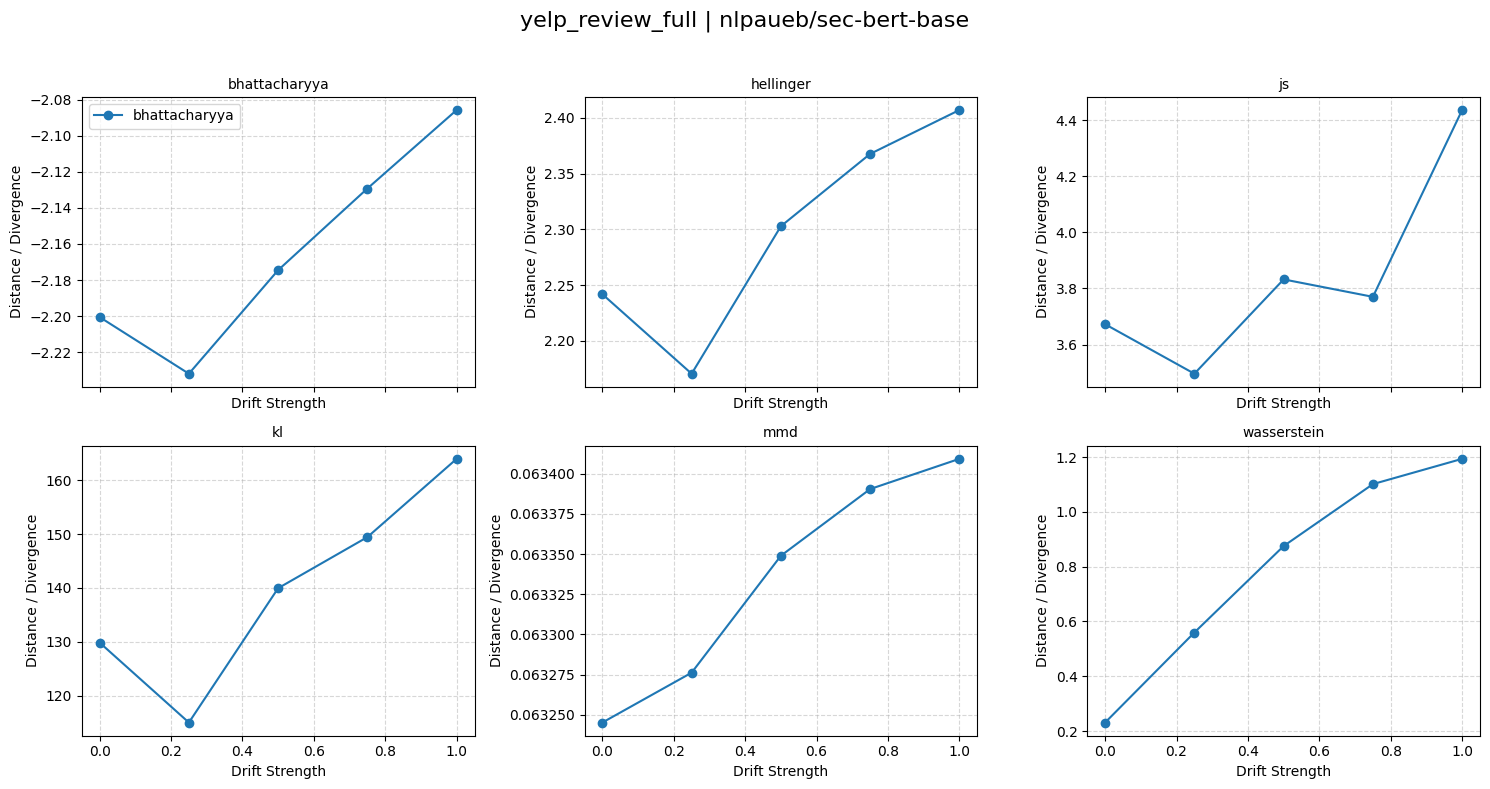

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distribution_measures.png


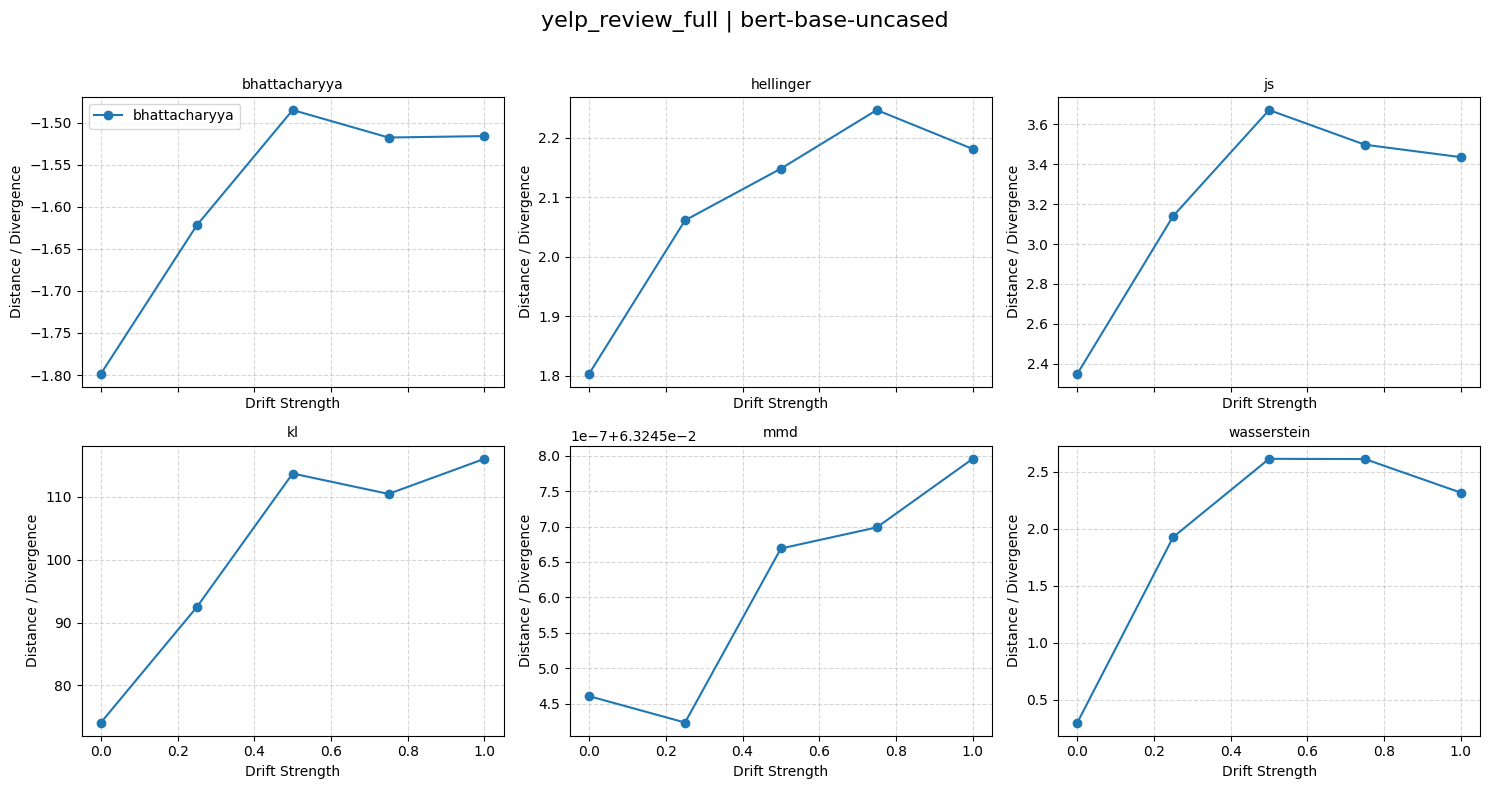

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distribution_measures.png


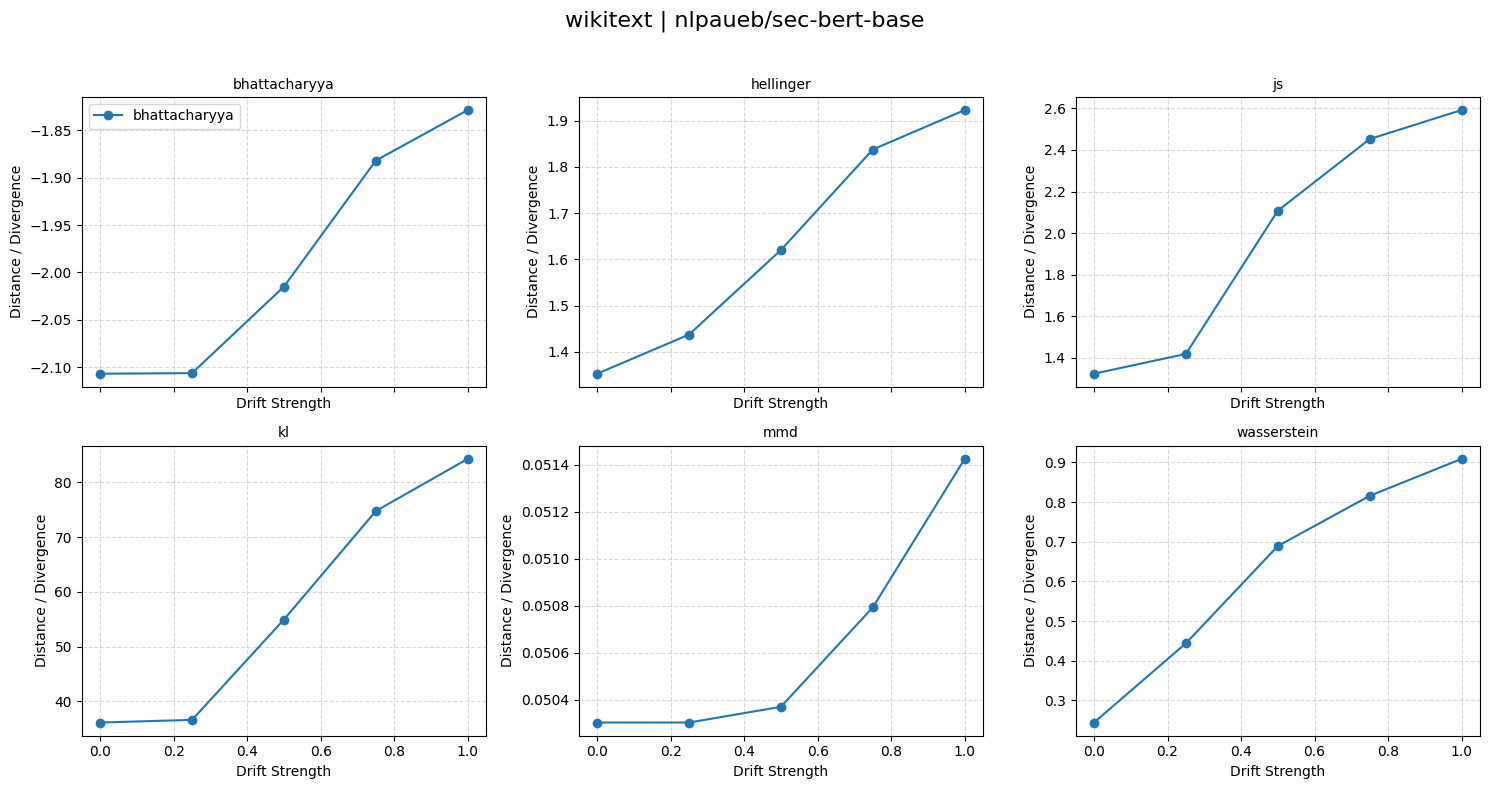

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distribution_measures.png


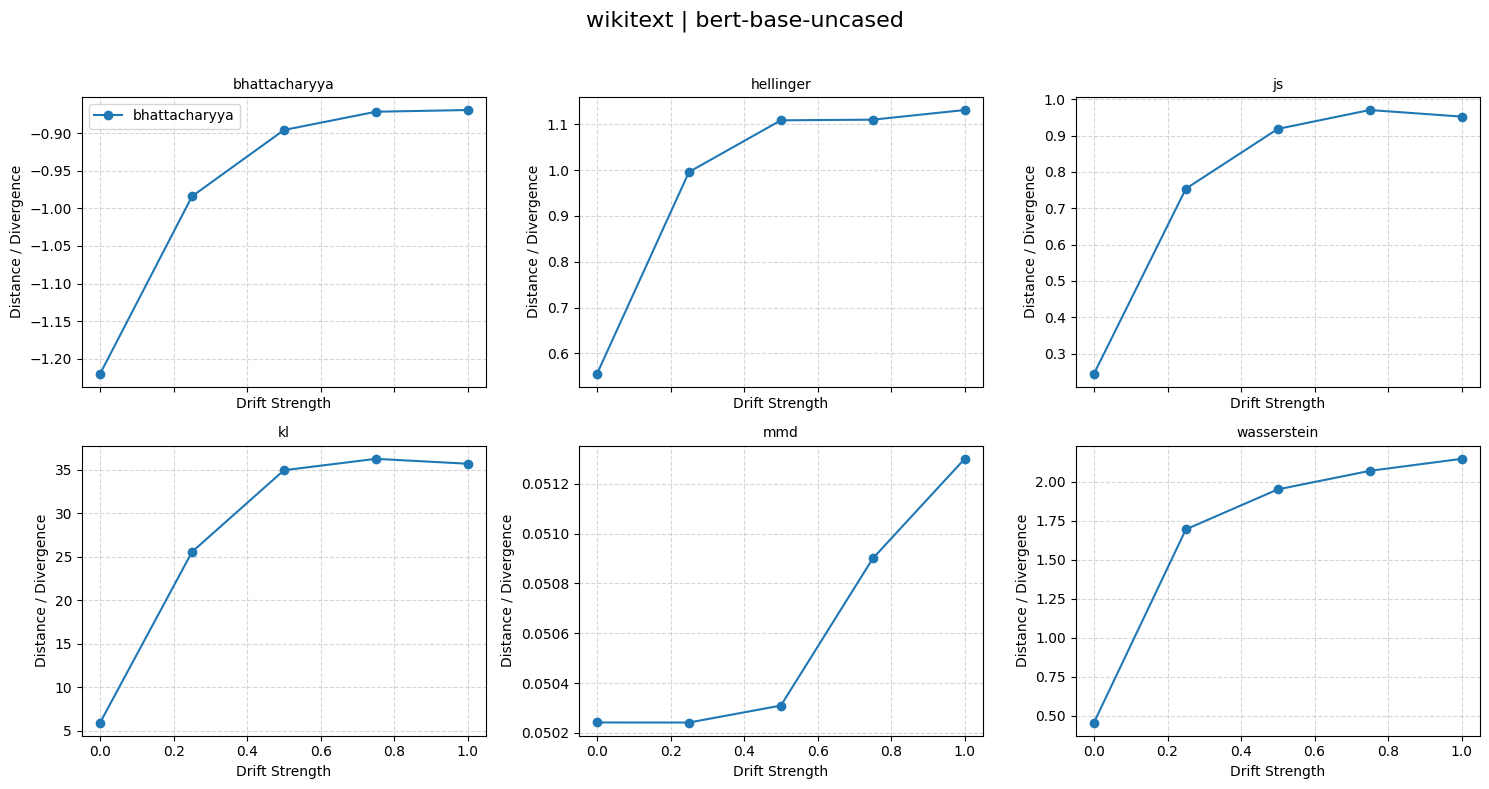

Saved figure: results_multidataset/wikitext_bert-base-uncased_distribution_measures.png


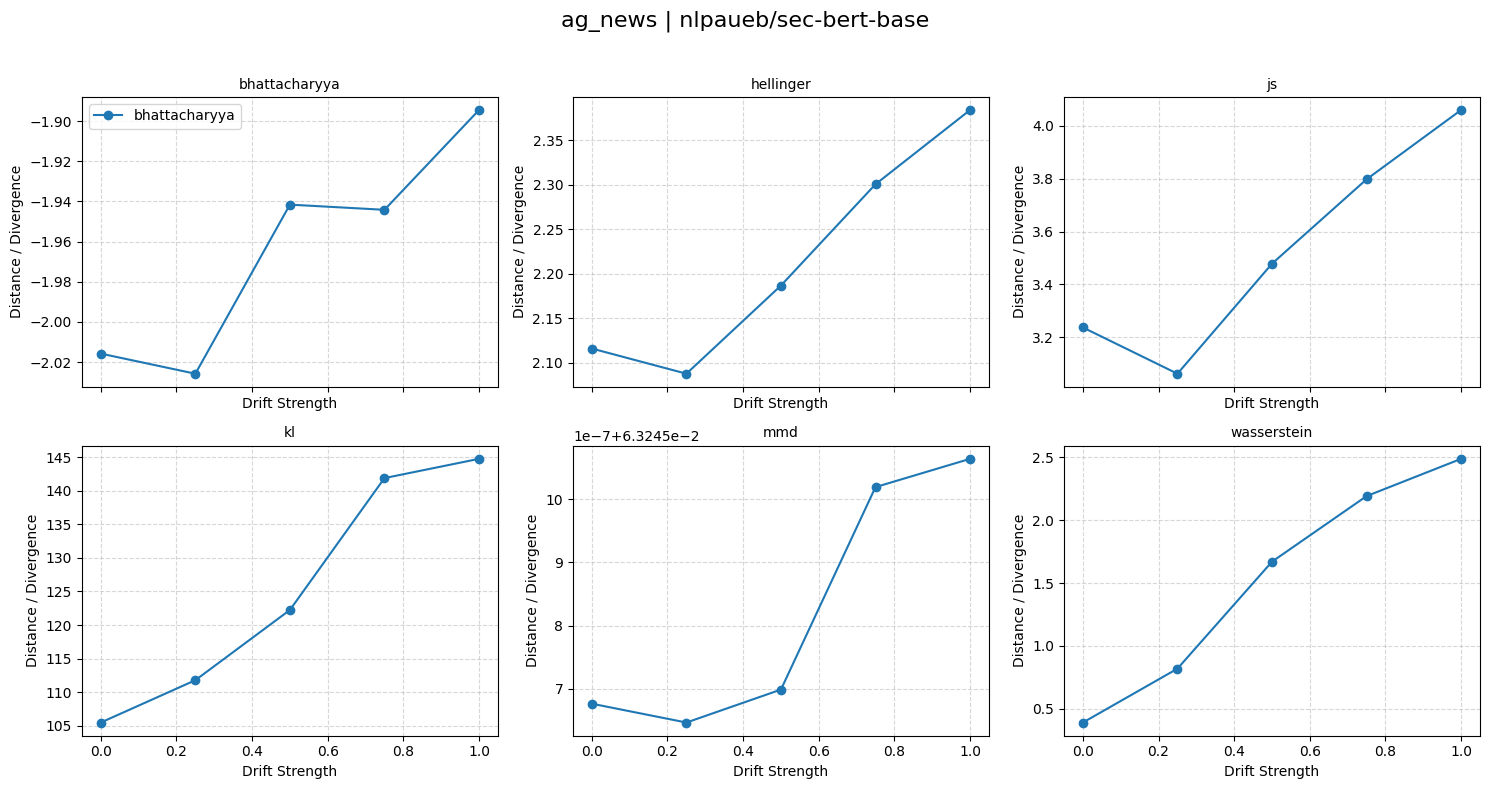

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distribution_measures.png


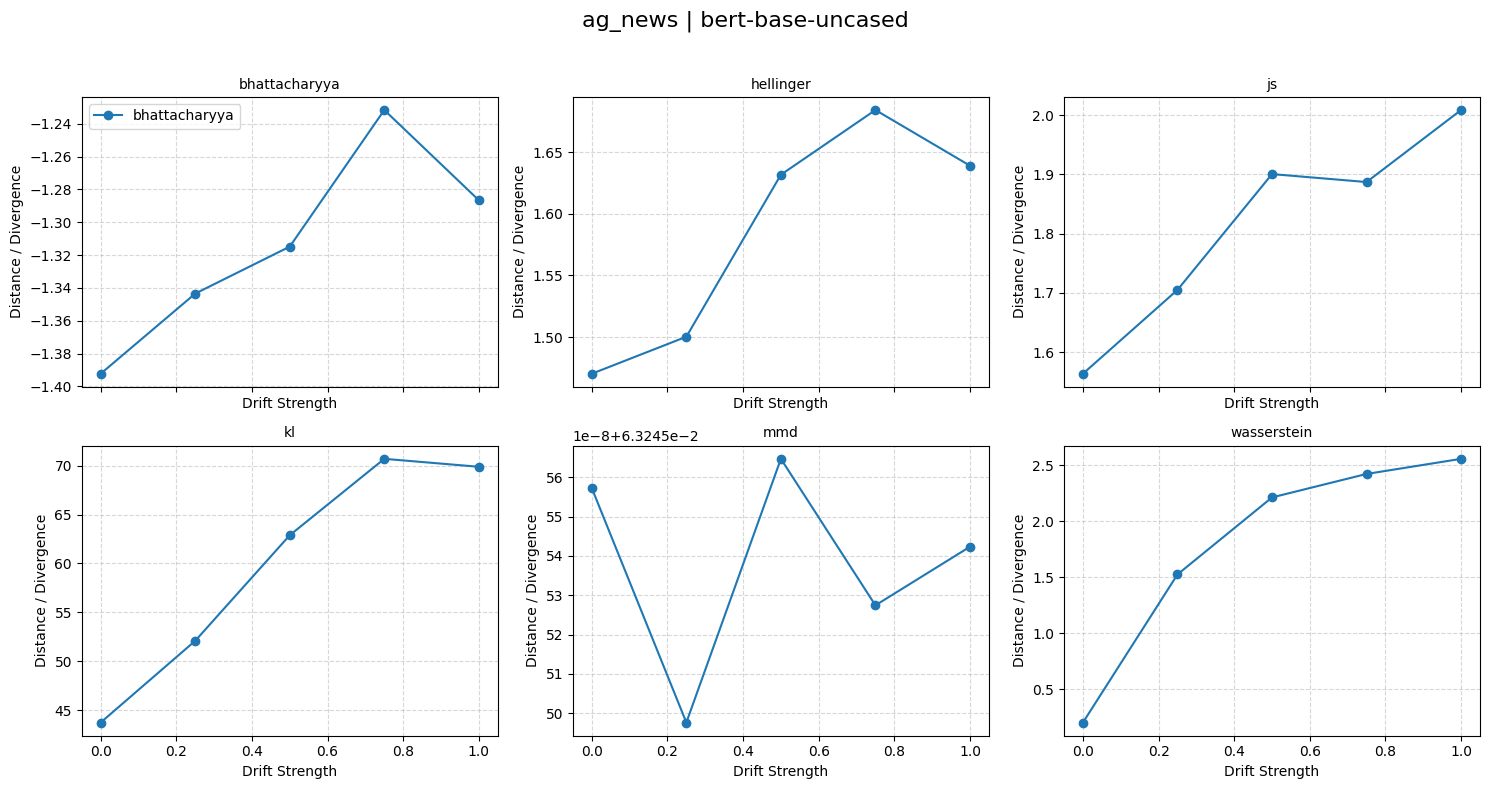

Saved figure: results_multidataset/ag_news_bert-base-uncased_distribution_measures.png


In [11]:
def plot_distribution_distances(all_results, output_dir="results_multidataset"):
    """
    For each (dataset_name, model_name) in all_results, we create ONE figure
    that has multiple subplots—one for each distribution-based measure_name.
    """
    for (dataset_name, model_name), runs in all_results.items():
        # Gather all measure names that were used
        measure_names = sorted(list({r["measure_name"] for r in runs}))
        n_measures = len(measure_names)

        # Decide on a grid layout (e.g. 3 columns)
        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)

        # Create figure and axes
        fig, axs = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True
        )
        axs = axs.flatten()  # Flatten in case we have multiple rows

        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, measure in enumerate(measure_names):
            ax = axs[i]

            # Filter runs for this measure_name
            measure_runs = [r for r in runs if r["measure_name"] == measure]
            # Sort by drift_strength
            measure_runs = sorted(measure_runs, key=lambda x: x["drift_strength"])

            # Extract x=drift_strength, y=distance_value
            x_vals = [run["drift_strength"] for run in measure_runs]
            y_vals = [run["distance_value"] for run in measure_runs]

            # Plot
            ax.plot(x_vals, y_vals, marker="o", label=measure)

            ax.set_title(measure, fontsize=10)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance / Divergence")
            ax.grid(True, linestyle="--", alpha=0.5)

            if i == 0:
                ax.legend()

        # Hide any leftover subplots if n_measures < n_rows * n_cols
        for j in range(i + 1, n_rows * n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])  # space for suptitle

        # Save figure
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path)
        plt.show()
        print(f"Saved figure: {save_path}")


plot_distribution_distances(all_results, output_dir=args["output_dir"])

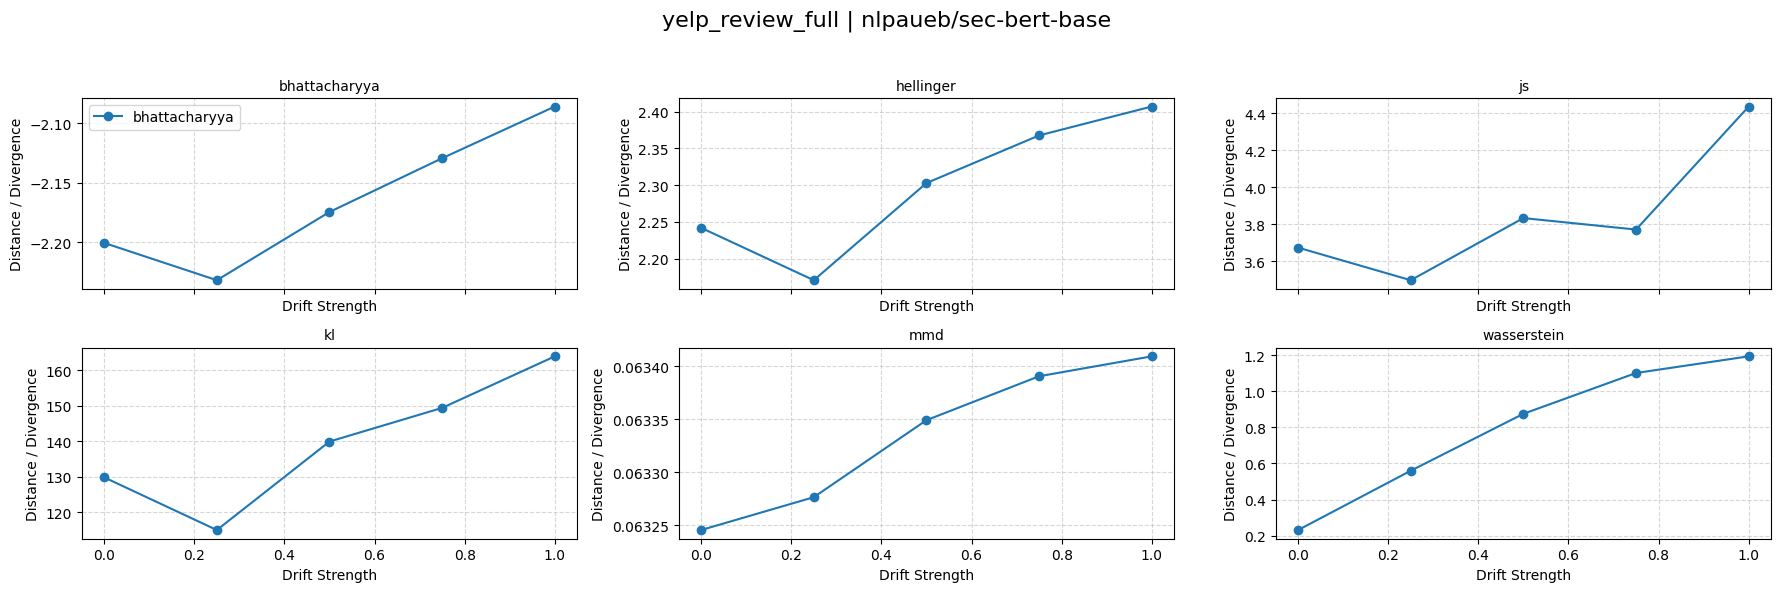

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distribution_measures.png


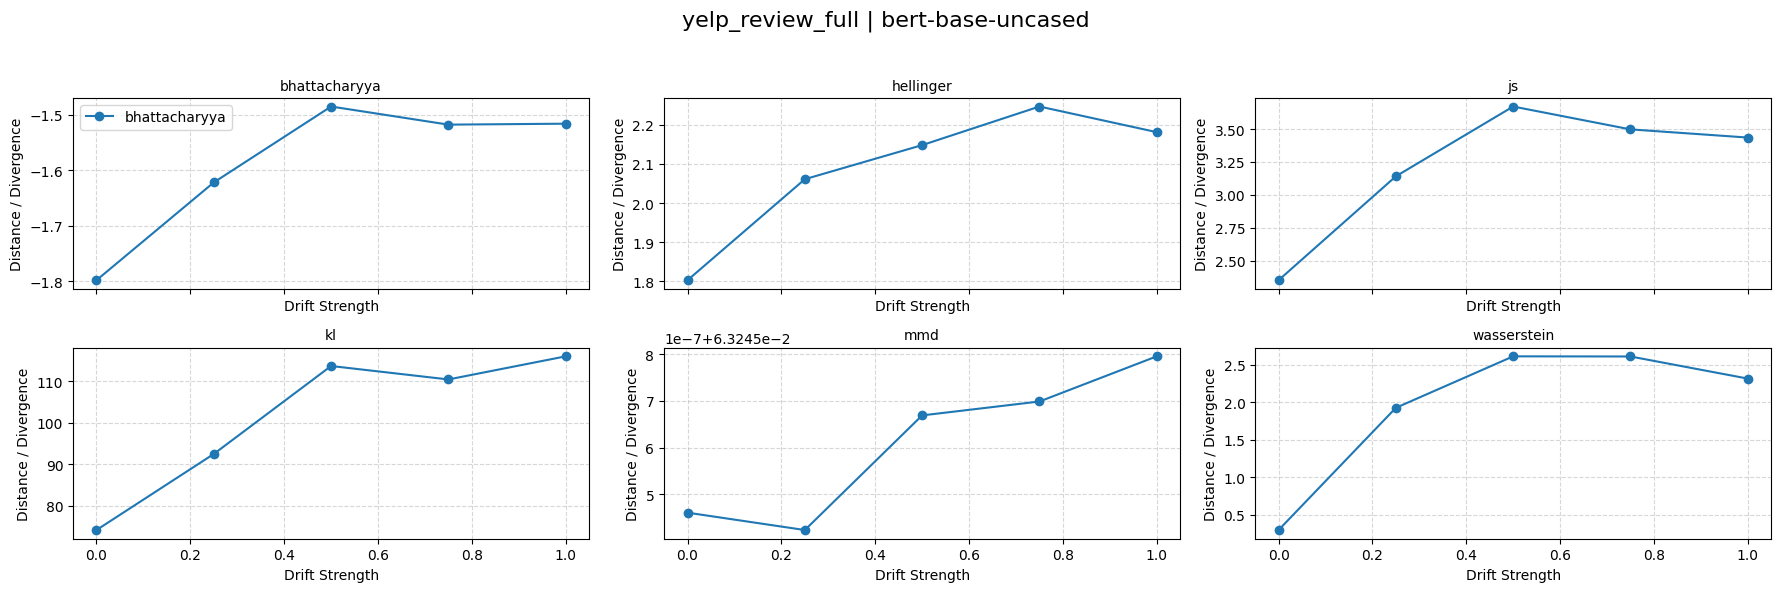

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distribution_measures.png


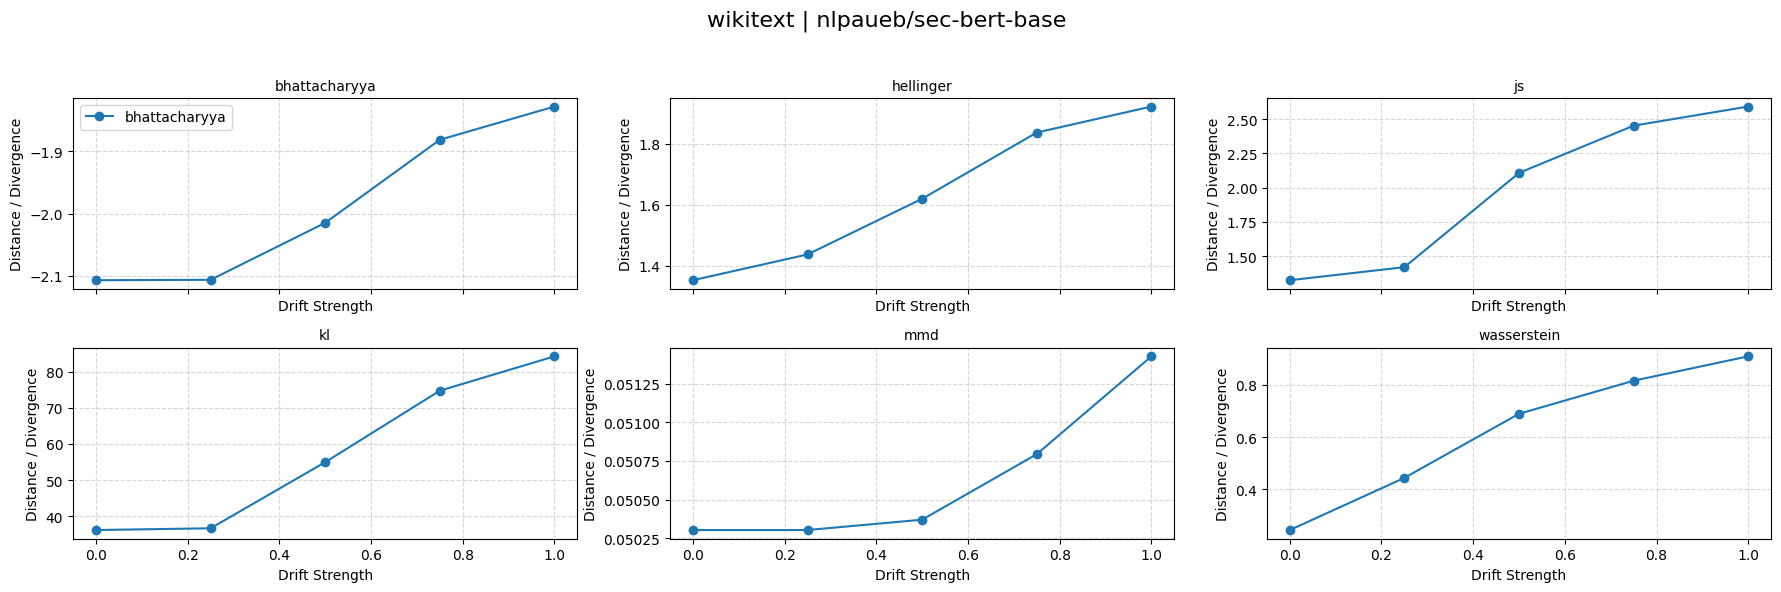

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distribution_measures.png


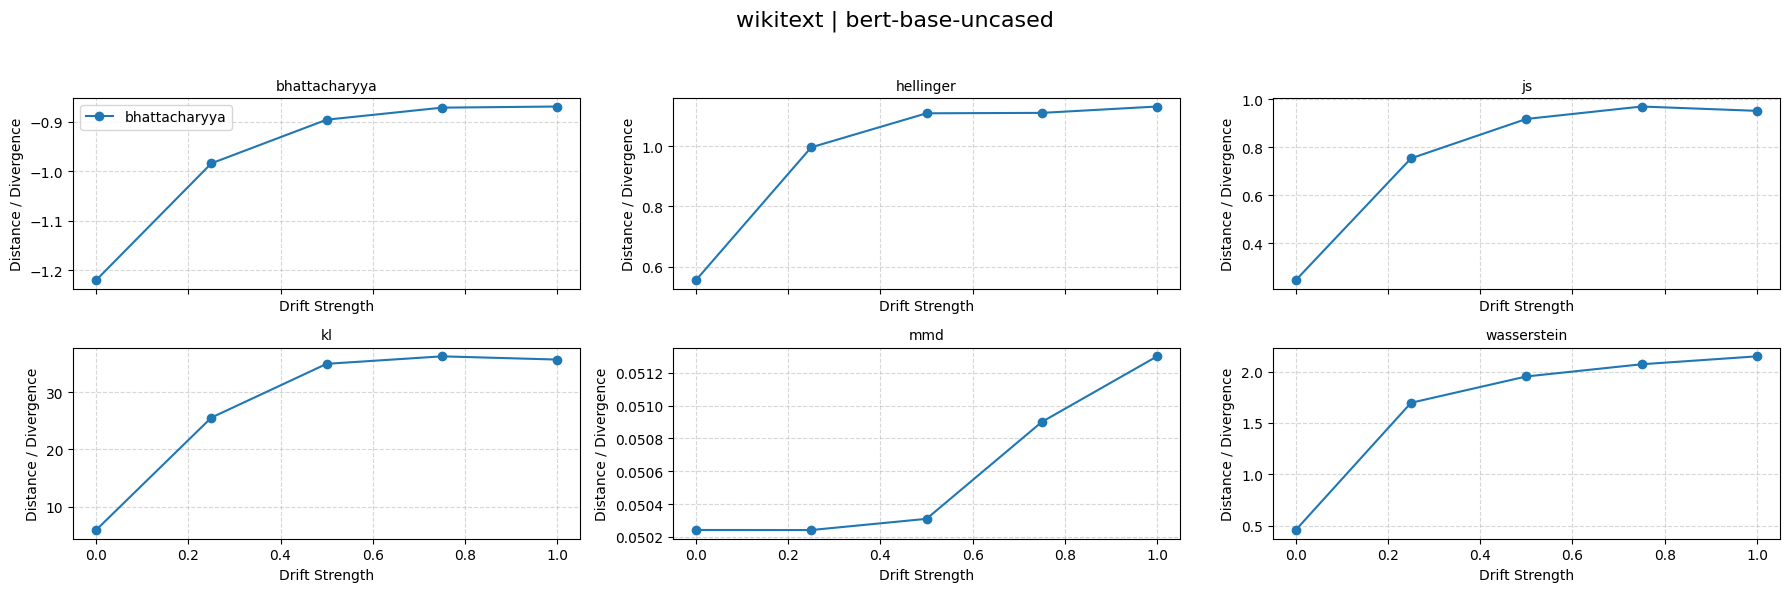

Saved figure: results_multidataset/wikitext_bert-base-uncased_distribution_measures.png


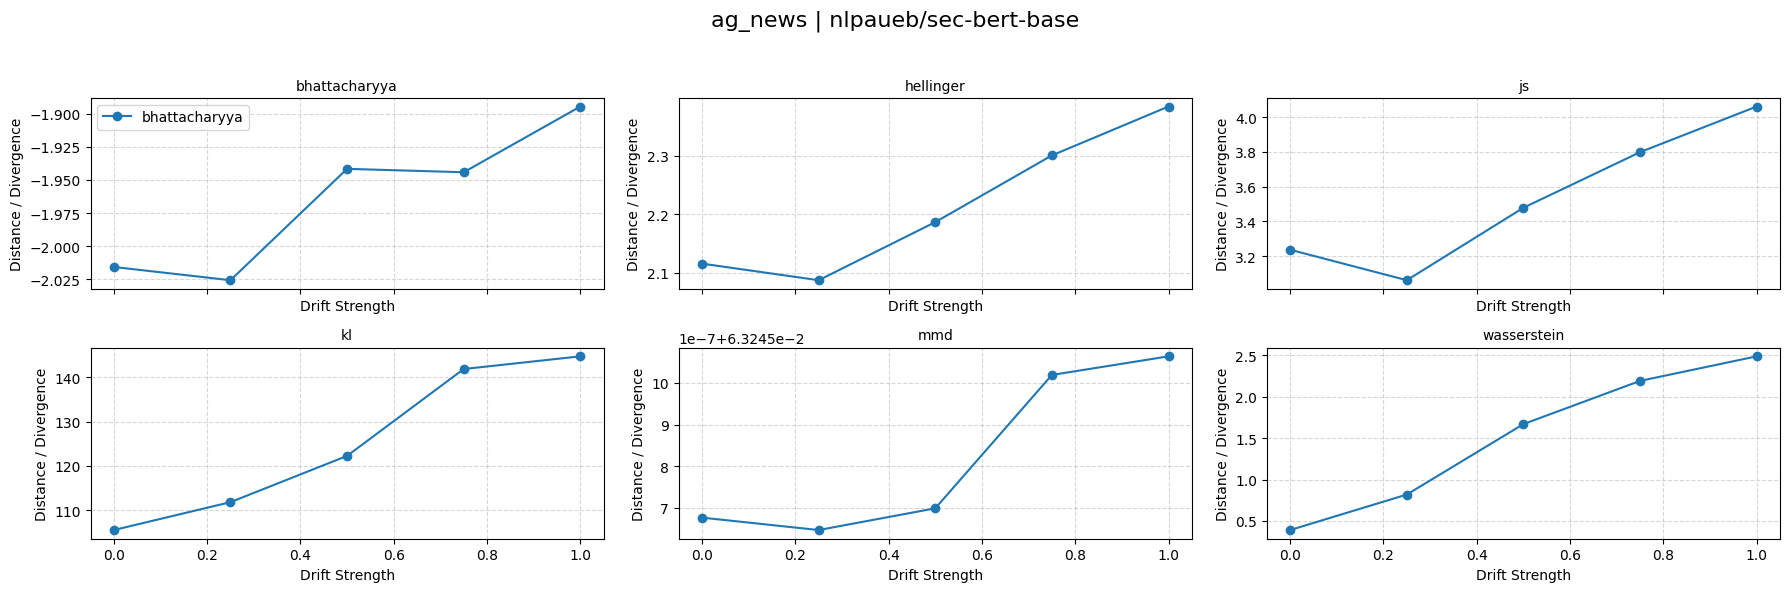

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distribution_measures.png


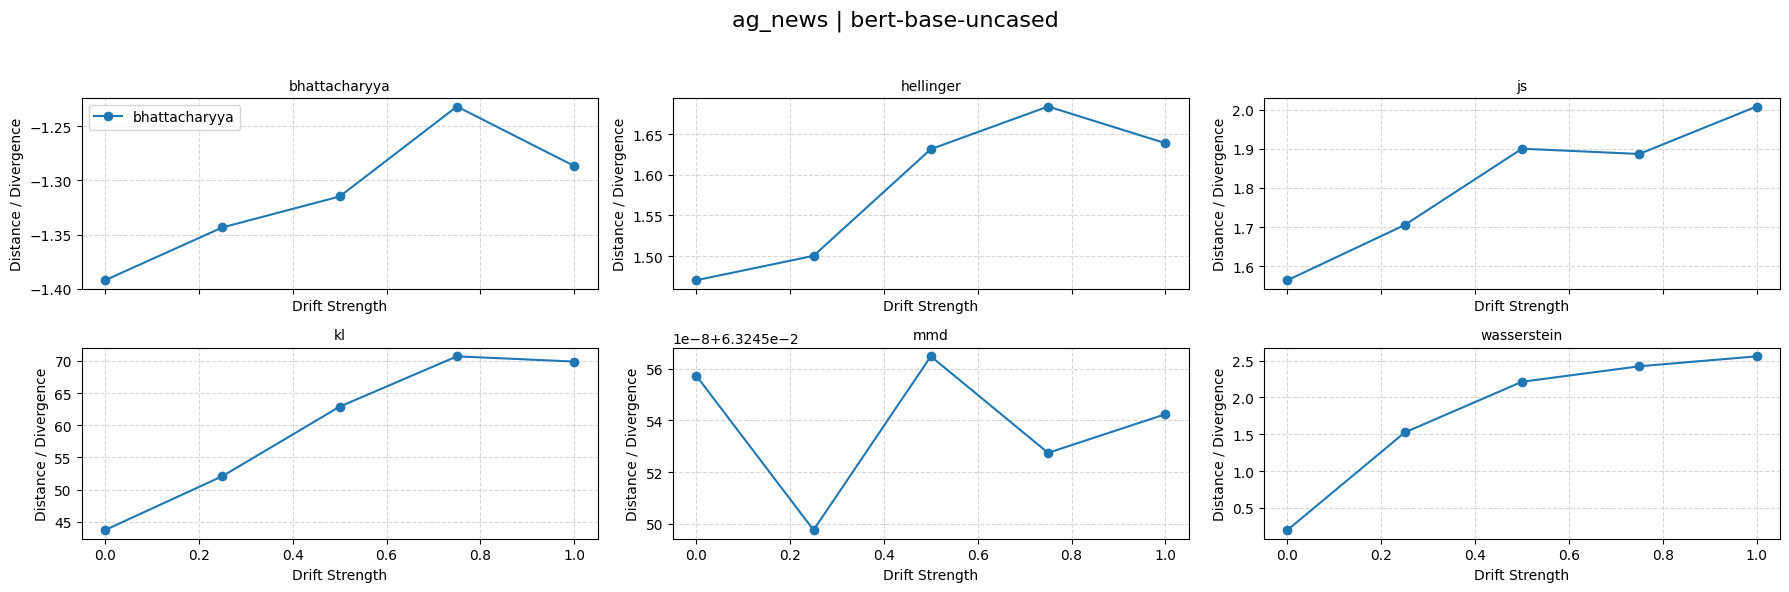

Saved figure: results_multidataset/ag_news_bert-base-uncased_distribution_measures.png


In [10]:
import math
import os


def plot_distribution_distances(all_results, output_dir="results_multidataset"):
    """
    For each (dataset_name, model_name) in all_results, we create ONE figure
    that has multiple subplots—one for each distribution-based measure_name.
    """
    for (dataset_name, model_name), runs in all_results.items():
        # Gather all measure names that were used
        measure_names = sorted(list({r["measure_name"] for r in runs}))
        n_measures = len(measure_names)

        # Decide on a grid layout (e.g., 3 columns)
        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)

        # Create figure and axes with adjusted figsize
        fig, axs = plt.subplots(
            n_rows,
            n_cols,
            figsize=(6 * n_cols, 3 * n_rows),  # Wider aspect ratio
            sharex=True,
        )
        axs = axs.flatten()  # Flatten in case we have multiple rows

        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, measure in enumerate(measure_names):
            ax = axs[i]

            # Filter runs for this measure_name
            measure_runs = [r for r in runs if r["measure_name"] == measure]
            # Sort by drift_strength
            measure_runs = sorted(measure_runs, key=lambda x: x["drift_strength"])

            # Extract x=drift_strength, y=distance_value
            x_vals = [run["drift_strength"] for run in measure_runs]
            y_vals = [run["distance_value"] for run in measure_runs]

            # Plot
            ax.plot(x_vals, y_vals, marker="o", label=measure)

            ax.set_title(measure, fontsize=10)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance / Divergence")
            ax.grid(True, linestyle="--", alpha=0.5)

            if i == 0:
                ax.legend()

        # Hide any leftover subplots if n_measures < n_rows * n_cols
        for j in range(i + 1, n_rows * n_cols):
            axs[j].set_visible(False)

        # Adjust layout with less padding
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Reduced space for suptitle

        # Save figure
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures_long.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path, dpi=300)  # High resolution for saving
        plt.show()
        print(f"Saved figure: {save_path}")


plot_distribution_distances(all_results, output_dir=args["output_dir"])